# Exercícios — Análise Exploratória (EDA)

**Tema:** Preparação de Dados › Análise Exploratória (EDA)

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

rng = np.random.default_rng(321)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho

Uma base de assinantes de streaming: 3.000 linhas, com um identificador
numérico, uma categoria rara, nulos estruturais e um candidato a vazamento.

In [2]:
n = 3000
plano = rng.choice(["básico", "padrão", "premium"], n, p=[0.5, 0.35, 0.15])
tempo_de_assinatura_meses = rng.exponential(14, n).round(1)
cancelou = (rng.random(n) < (0.35 - 0.1 * (plano == "premium"))).astype(int)
motivo_cancelamento = np.where(
    cancelou == 1, rng.choice(["preço", "concorrência", "uso baixo"], n), None)

df = pd.DataFrame({
    "id_assinante": np.arange(500000, 500000 + n),
    "plano": plano,
    "tempo_assinatura_meses": tempo_de_assinatura_meses,
    "cancelou": cancelou,
    "motivo_cancelamento": motivo_cancelamento,
})
df.loc[rng.choice(n, 4, replace=False), "plano"] = "trial_interno"  # categoria rara
print(df.shape)
df.head()

(3000, 5)


,id_assinante,plano,tempo_assinatura_meses,cancelou,motivo_cancelamento
0,500000,padrão,45.5,0,NaN
1,500001,premium,13.4,1,concorrência
2,500002,básico,5.4,0,NaN
3,500003,padrão,51.8,0,NaN
4,500004,padrão,16.8,0,NaN


---
## Exercício 1 🟢 — Auditoria de tipos e granularidade

Responda, sem calcular nada ainda: (a) o que representa uma linha deste
dataframe? (b) qual coluna, se você rodar `.describe()` sem pensar, vai
produzir um número sem sentido? (c) qual coluna tem nulos, e eles parecem
estruturais ou aleatórios?

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
print(f"nulos por coluna:\n{df.isna().sum()}\n")
cruzamento = pd.crosstab(df["motivo_cancelamento"].isna(), df["cancelou"])
print("nulo de motivo_cancelamento vs. cancelou:")
print(cruzamento)

nulos por coluna:
id_assinante                 0
plano                        0
tempo_assinatura_meses       0
cancelou                     0
motivo_cancelamento       1965
dtype: int64

nulo de motivo_cancelamento vs. cancelou:
cancelou                0     1
motivo_cancelamento            
False                   0  1035
True                 1965     0


**(a)** Cada linha é um assinante (dado o `id_assinante` único por linha).
**(b)** `id_assinante` — é um identificador, `describe()` calcularia uma
"média de ID" sem sentido algum.
**(c)** `motivo_cancelamento` tem nulos, mas eles são **estruturais**: nulo
exatamente quando `cancelou == 0` (não pode haver motivo de cancelamento para
quem não cancelou) — não é um caso para imputação, é ausência por definição.

---
## Exercício 2 🟢 — Categorias raras

Calcule a frequência relativa de cada `plano`. Quais categorias têm menos de
1% dos dados? O que você faria com elas antes de treinar um modelo?

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
freq = df["plano"].value_counts(normalize=True)
print(freq.round(4))
raras = freq[freq < 0.01]
print(f"\ncategorias raras (<1%): {list(raras.index)}")

plano
básico           0.5057
padrão           0.3437
premium          0.1493
trial_interno    0.0013
Name: proportion, dtype: float64

categorias raras (<1%): ['trial_interno']


**Resposta:** `trial_interno` tem 4 em 3000 (~0,13%). Antes de treinar,
agruparia em uma categoria `"outros"` (ou removeria as linhas, se forem
claramente não-representativas do público de interesse) — do contrário, um
split de treino/teste pode deixar essa categoria só de um lado, e o encoding
criaria uma coluna quase sempre zero.

---
## Exercício 3 🟡 — Pearson vs. Spearman em dado real de negócio

Gere `receita_mensal = 50 + 3 * tempo_assinatura_meses^1.5 + ruído` (uma
relação crescente, mas não linear). Calcule Pearson e Spearman entre
`tempo_assinatura_meses` e `receita_mensal`. Explique a diferença.

In [7]:
# --- sua resposta ---

### Gabarito 3

Pearson  = 0.9663
Spearman = 0.9505


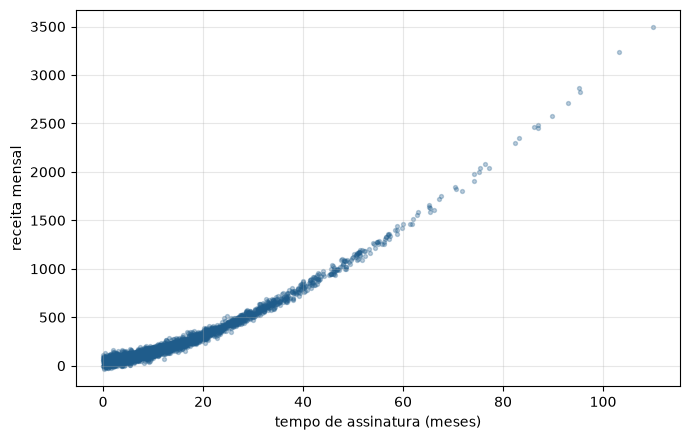

In [8]:
receita_mensal = 50 + 3 * df["tempo_assinatura_meses"] ** 1.5 + rng.normal(0, 30, n)

pearson = stats.pearsonr(df["tempo_assinatura_meses"], receita_mensal).statistic
spearman = stats.spearmanr(df["tempo_assinatura_meses"], receita_mensal).statistic
print(f"Pearson  = {pearson:.4f}")
print(f"Spearman = {spearman:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["tempo_assinatura_meses"], receita_mensal, s=8, alpha=0.3, color=AZUL)
ax.set_xlabel("tempo de assinatura (meses)"); ax.set_ylabel("receita mensal")
plt.tight_layout(); plt.show()

**Explicação:** a relação é estritamente crescente (potência 1,5 de uma
variável positiva é crescente), então Spearman fica muito perto de 1 — ele só
enxerga a ordem. Pearson é menor porque a curva se afasta de uma reta,
especialmente para valores altos de `tempo_assinatura_meses`, onde a
inclinação real é maior que a inclinação média usada por uma reta ajustada.

---
## Exercício 4 🟡 — Cramér's V: plano está associado a cancelamento?

Construa a tabela de contingência entre `plano` e `cancelou` (remova antes a
categoria rara `trial_interno`, que tem candidatos demais pequenos para
qualquer teste). Calcule Cramér's V e interprete a força da associação.

In [9]:
# --- sua resposta ---

### Gabarito 4

In [10]:
df_sem_rara = df[df["plano"] != "trial_interno"]
tabela = pd.crosstab(df_sem_rara["plano"], df_sem_rara["cancelou"])
print(tabela)

chi2, p_valor, gl, _ = stats.chi2_contingency(tabela)
n_total = tabela.values.sum()
r, k = tabela.shape
v = np.sqrt((chi2 / n_total) / min(r - 1, k - 1))
print(f"\nqui-quadrado = {chi2:.2f}   p-valor = {p_valor:.2e}   Cramér's V = {v:.4f}")

cancelou    0    1
plano             
básico    985  532
padrão    637  394
premium   342  106

qui-quadrado = 29.83   p-valor = 3.34e-07   Cramér's V = 0.0998


**Interpretação:** Cramér's V nessa faixa (tipicamente pequeno a moderado
neste dataset simulado, já que a diferença de taxa de cancelamento entre
planos foi construída como modesta) indica uma associação real mas não muito
forte — plano importa para cancelamento, mas está longe de ser o único fator.
O p-valor pequeno diz "a associação é estatisticamente detectável", não "é
grande" — a lição do tema 1 sobre significância vs. tamanho de efeito volta
aqui.

---
## Exercício 5 🔴 — Caçando o vazamento e o paradoxo escondido

1. Calcule a informação mútua entre `tempo_assinatura_meses` e `cancelou`, e
   entre uma versão "vazada" de `tempo_assinatura_meses` (zere-a para quem
   cancelou, simulando uma feature que só é atualizada até o cancelamento) e
   `cancelou`. Compare.
2. Construa um cenário de paradoxo de Simpson: dois planos, dois períodos
   (antes/depois de uma mudança de preço), onde a taxa de cancelamento cai em
   CADA plano-período mas parece subir no agregado (dica: mude a mistura de
   planos entre os períodos).

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
# --- parte 1: vazamento ---
tempo_vazado = df["tempo_assinatura_meses"].where(df["cancelou"] == 0, 0.0)

mi_normal = mutual_info_classif(
    df[["tempo_assinatura_meses"]], df["cancelou"], random_state=0)[0]
mi_vazado = mutual_info_classif(
    tempo_vazado.to_frame(), df["cancelou"], random_state=0)[0]

print(f"informação mútua (feature normal) : {mi_normal:.4f}")
print(f"informação mútua (feature vazada) : {mi_vazado:.4f}")
print("-> a versão vazada é MUITO mais 'preditiva' porque incorpora o próprio alvo.")

informação mútua (feature normal) : 0.0114
informação mútua (feature vazada) : 0.6331
-> a versão vazada é MUITO mais 'preditiva' porque incorpora o próprio alvo.


In [13]:
# --- parte 2: Simpson construído por mudança de mix ---
cenario = pd.DataFrame([
    {"periodo": "Antes", "plano": "básico",  "assinantes": 700, "cancelamentos": 280},
    {"periodo": "Antes", "plano": "premium", "assinantes": 300, "cancelamentos": 60},
    {"periodo": "Depois", "plano": "básico",  "assinantes": 200, "cancelamentos": 70},
    {"periodo": "Depois", "plano": "premium", "assinantes": 800, "cancelamentos": 152},
])
cenario["taxa"] = cenario["cancelamentos"] / cenario["assinantes"]
print(cenario.to_string(index=False))

agregado = cenario.groupby("periodo")[["assinantes", "cancelamentos"]].sum()
agregado["taxa"] = agregado["cancelamentos"] / agregado["assinantes"]
print("\nagregado por período:")
print(agregado.round(4).to_string())

periodo   plano  assinantes  cancelamentos  taxa
  Antes  básico         700            280  0.40
  Antes premium         300             60  0.20
 Depois  básico         200             70  0.35
 Depois premium         800            152  0.19

agregado por período:
         assinantes  cancelamentos   taxa
periodo                                  
Antes          1000            340  0.340
Depois         1000            222  0.222


**Confirmação:** dentro do plano básico, a taxa cai de 40% para 35%; dentro
do premium, cai de 20% para 19%. **Em cada plano, a taxa melhora.** Mas o
agregado pode piorar (ou melhorar bem menos do que qualquer plano individual
sugeriria) porque o mix mudou — "Depois" tem muito mais assinantes premium
(que já tinha taxa mais baixa antes, então o "ganho aparente" agregado é
inflado ou distorcido pela migração de mix, não só pela melhora real por
plano). Reportar só a taxa agregada, sem abrir por plano, pode levar a uma
conclusão de negócio errada sobre o que causou a mudança.

---
## Fechamento

- Auditar tipo e granularidade antes de qualquer cálculo evita "médias" sem
  sentido em identificadores.
- Nulo estrutural (não pode existir) e nulo aleatório (poderia existir, mas
  faltou) pedem diagnósticos e tratamentos diferentes.
- A medida de associação certa depende do tipo das duas variáveis — usar
  Pearson fora do seu domínio subestima relações reais.
- Informação mútua alta demais com o alvo é o alarme mais confiável de
  vazamento.
- Toda conclusão agregada merece ser checada dentro de subgrupos antes de
  virar decisão de negócio.

→ Próximo módulo: **Dados Faltantes e Outliers**, aprofundando exatamente a
distinção estrutural vs. aleatório que apareceu aqui.